# CLR transforms vs Dirichlet–multinomial — and what median-of-ratios does

Companion to `dirichlet-multinomial-simulation.ipynb` and
`dm-overexpression-identifiability.ipynb`. Two questions:

1. **Do centered log-ratio (CLR) transforms fill the same role as the Dirichlet–multinomial?**
2. **What exactly does a median-of-ratios (MoR) size factor *do* to the estimates?**

**TL;DR**

* **No — complementary layers, not substitutes.** CLR is a *deterministic transform* on
  compositions (Aitchison geometry, bijective onto the sum-zero hyperplane); the
  DM is a *generative model* of how counts arise (multinomial sampling ⊕ Dirichlet
  overdispersion ⊕ library sizes). CLR has no noise model, no zeros handling
  (log of 0 ⇒ pseudocount hacks), no likelihood, no $\theta$; the DM has no geometry,
  no covariance flexibility (all log-composition pairs are forced *negative*:
  $\operatorname{Cov}(\log p_i,\log p_j) = -\psi'(\alpha_0)$). The honest CLR-land
  analog of the DM is the **logistic-normal(-multinomial)**; in practice they are
  combined (ALDEx2 ≈ Dirichlet Monte-Carlo → clr → Welch t).
* **CLR changes no identifiability outcome.** It is a bijection of the simplex — it
  *re-expresses* the composition shifts in log-ratio units and inherits all the
  mirror/global-shift limits from the previous notebook.
* **MoR is an anchor estimator.** Its size factors
  $s_s=\mathrm{median}_i(y_{si}/g_i)$ make each estimate an *anchor-relative* fold
  change (anchor = median category): it removes library-size/efficiency variation like
  plain depth-normalization *plus* it deletes (or distorts) any genome-wide signal, and
  it only returns true absolute folds when the anchor assumption holds.
* Demonstrated: closed-form log-composition moments of Dirichlet (trigamma) vs the
  logistic-normal's flexible correlations; pseudocount-dependence of clr on sparse
  categories (the answer swings by >1 log2 unit); calibration of tests (naive vs DM
  variance vs clr-Welch); MoR vs depth-normalization under rate noise with small-f and
  majority-f overexpression truths.

**The layered stack** (each layer answers a different question):

| layer | question it answers | DM | CLR |
|---|---|---|---|
| count noise (observation) | how do reads arise? | ✅ multinomial ⊕ Dirichlet | ❌ none — feeds off whatever you give it |
| composition geometry (sample) | *where in the simplex / log-ratio space* | implicit | ✅ bijective, isometric |
| normalization (across samples) | which scale to compare at | none (N is modeled) | built-in: geomean anchor |
| absolute scale | molecules | unidentifiable | unidentifiable (inherits) |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import scipy.special as sp
from IPython.display import display

%matplotlib inline

sns.set_theme(style="whitegrid", context="notebook")
rng = np.random.default_rng(20240614)
COL_A, COL_B, COL_M = "#4C72B0", "#DD8452", "#55A868"

print("numpy", np.__version__, "| pandas", pd.__version__, "| seaborn", sns.__version__)

numpy 2.5.3 | pandas 3.0.5 | seaborn 0.13.2


## 1. Transform vs distribution: the Dirichlet's rigid log-geometry, and the logistic-normal

CLR is defined on a *given* composition $x$ (positive, sums to 1):
$\mathrm{clr}_i = \log x_i - \frac{1}{K}\sum_j \log x_j$ — a bijection onto the sum-zero
hyperplane. It transforms geometry; it says **nothing about how $x$ varies**.

The DM, by contrast, ships closed-form moments for $\log p$. Under
$p\sim\operatorname{Dirichlet}(\alpha)$ with $\alpha_0=\sum\alpha_i$:

$$
\mathbb{E}[\log p_i] = \psi(\alpha_i)-\psi(\alpha_0),\qquad
\operatorname{Var}(\log p_i) = \psi'(\alpha_i)-\psi'(\alpha_0),\qquad
\operatorname{Cov}(\log p_i,\log p_j) = -\psi'(\alpha_0)\quad (i\ne j).
$$

Two consequences: (i) the moments are numerically checkable — we do that below;
(ii) the **between-category structure is rigid**: *every* pair of log-compositions is
negatively correlated by the same constant. Real co-occurrence (co-regulated genes,
syntrophic taxa) needs positive correlations — the Dirichlet structurally cannot
express them. The standard fix is the **logistic-normal**:
$\eta\sim\mathcal{N}(\mu,\Sigma),\; p = \operatorname{softmax}(\eta)$ — in clr-space
this is exactly Gaussian; its multinomial-mixed version (LNM) is the "true" analog of
the Dirichlet-multinomial. So: *CLR is the coordinate system; the distribution question
is whether you model log-compositions as Dirichlet-flavored (rigid) or
logistic-normal (flexible)* — CLR alone plays no role in that choice.

max |empirical − theoretical corr|: 0.0170
DM:  corr(log p_0, log p_1) = -0.070   (theory −ψ′(α0)/√vv = -0.078) — negative for EVERY pair
LN:  corr(log p_0, log p_1) = +0.399 inside block (positive!), cross-block -0.381


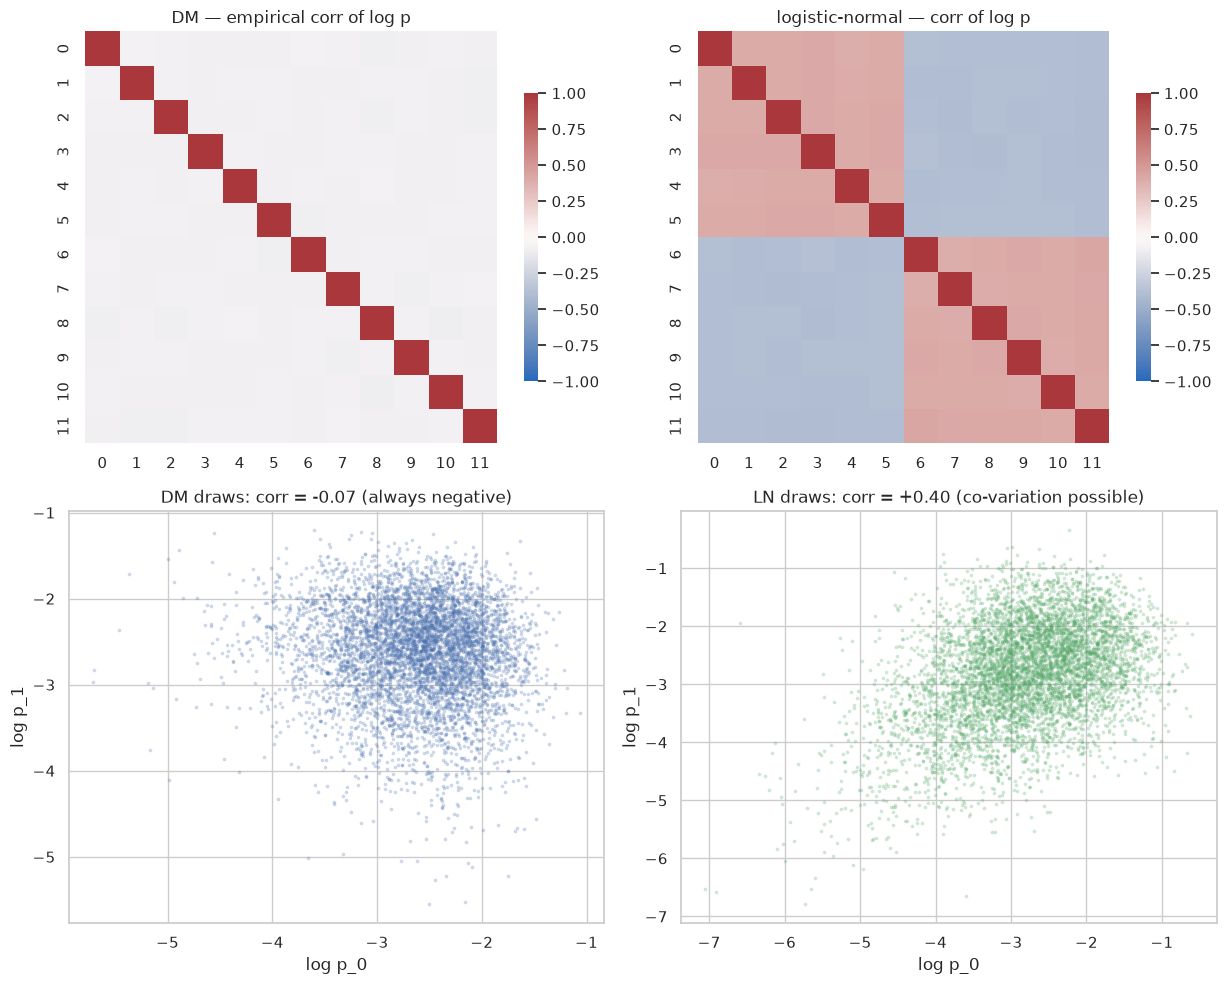

In [2]:
# --- DM: empirical vs closed-form log-composition correlations ---------------
K1, THETA1 = 12, 40.0
pi1 = np.full(K1, 1.0 / K1)
alpha1 = THETA1 * pi1

P_dm = np.vstack([rng.dirichlet(alpha1) for _ in range(40_000)])
logP = np.log(P_dm)
emp_corr = np.corrcoef(logP, rowvar=False)

theo_cov = -sp.polygamma(1, alpha1.sum()) * np.ones((K1, K1))     # off-diag: −ψ′(α0)
np.fill_diagonal(theo_cov, sp.polygamma(1, alpha1) - sp.polygamma(1, alpha1.sum()))
theo_corr = theo_cov / np.sqrt(np.outer(np.diag(theo_cov), np.diag(theo_cov)))

print("max |empirical − theoretical corr|:", f"{np.abs(emp_corr - theo_corr).max():.4f}")

# --- Logistic-normal: flexible correlations DM cannot express ---------------
K2 = 12
Sig = np.full((K2, K2), -0.05)
Sig[:6, :6] = 0.55
Sig[6:, 6:] = 0.55
np.fill_diagonal(Sig, 1.0)
np.linalg.cholesky(Sig)                      # assert positive-definite

eta = rng.multivariate_normal(np.zeros(K2), Sig, size=8000)
eta -= eta.max(1, keepdims=True)
P_ln = np.exp(eta) / np.exp(eta).sum(1, keepdims=True)
logP_ln = np.log(P_ln)
corr_ln = np.corrcoef(logP_ln, rowvar=False)

print(f"DM:  corr(log p_0, log p_1) = {emp_corr[0, 1]:+.3f}   (theory −ψ′(α0)/√vv = "
      f"{theo_corr[0, 1]:+.3f}) — negative for EVERY pair")
print(f"LN:  corr(log p_0, log p_1) = {corr_ln[0, 1]:+.3f} inside block (positive!), "
      f"cross-block {corr_ln[0, 6]:+.3f}")

fig, axes = plt.subplots(2, 2, figsize=(12.5, 10.0))
for ax_, corr, ttl in [(axes[0, 0], emp_corr, "DM — empirical corr of log p"),
                       (axes[0, 1], corr_ln, "logistic-normal — corr of log p")]:
    sns.heatmap(corr, cmap="vlag", vmin=-1, vmax=1, center=0, square=True,
                cbar_kws={"shrink": 0.7}, ax=ax_)
    ax_.set_title(ttl)
axes[1, 0].scatter(logP[:6000, 0], logP[:6000, 1], s=3, alpha=0.2, color=COL_A)
axes[1, 0].set(xlabel="log p_0", ylabel="log p_1",
               title=f"DM draws: corr = {emp_corr[0, 1]:+.2f} (always negative)")
axes[1, 1].scatter(logP_ln[:6000, 0], logP_ln[:6000, 1], s=3, alpha=0.2, color=COL_M)
axes[1, 1].set(xlabel="log p_0", ylabel="log p_1",
               title=f"LN draws: corr = {corr_ln[0, 1]:+.2f} (co-variation possible)")
fig.tight_layout()

## 2. Where they genuinely differ: zeros

Multinomial/DM sampling produces zeros *naturally and cheaply* — a category absent from a
sample is just an event with probability ≥ 0, and every count-level model (DM likelihood,
beta-binomial, DM regression) handles it without a second thought.

CLR is undefined at $x_i = 0$. Every clr pipeline must therefore *replace* zeros
(multiplicative replacement, Bayesian-multiplicative, or a bare pseudocount). The
replacement is not innocuous: for a sparse category the estimated clr difference depends
strongly on the arbitrary constant. The count-model estimate
$\log_2(\bar x^{B}_i / \bar x^{A}_i)$ — which simply averages proportions *including*
zeros — needs no such choice and is stable.

Below: one rare category ($\pi = 10^{-3}$, i.e. ~30 counts per sample at $N=30{,}000$)
under moderate overdispersion ($\theta=100$), overexpressed ×20 in absolute terms in B.
Dirichlet mixing still leaves the majority of samples drawing this category's latent
proportion near zero → ~40% of observed counts are 0 in A (measured live below), and
even a 15-replicate prop-ratio estimate stays tight — while the clr estimate moves
several log2 units as the pseudocount changes.

material multiplier C = 1.0190 (one rare category ×20 barely moves the pool)
representative replicate: zero rate rare category A = 57% | B = 0%
true composition fold: +4.29
  clr, pseudocount    0.5: median +5.04
  clr, pseudocount      2: median +4.22
  clr, pseudocount     10: median +3.12
  clr, pseudocount     50: median +2.02
  clr, pseudocount    200: median +1.11
  prop-ratio (count model): median +4.38


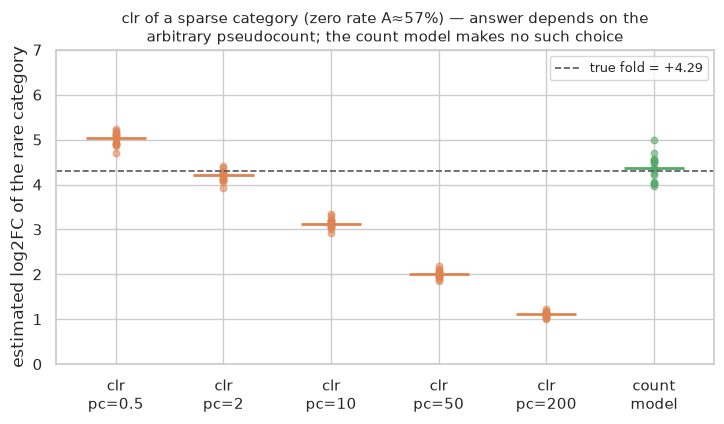

In [3]:
def make_pi(K, rng, sigma=1.0, sort_descending=True):
    a = rng.lognormal(0.0, sigma, K)
    if sort_descending:
        a = np.sort(a)[::-1]
    return a / a.sum()


def fold_pi(pi, mask, factor):
    m = np.ones(len(pi))
    m[mask] = factor
    pi2 = pi * m
    return pi2 / pi2.sum(), float(pi2.sum())


def mean_proportion(counts, N):
    return (counts / N[:, None]).mean(axis=0)


def simulate_group(pi, theta, n, census_factor=1.0, med_n=20_000, sigma_n=0.35, rng=None):
    P = np.vstack([rng.dirichlet(theta * pi) for _ in range(n)])
    N = np.round(rng.lognormal(np.log(med_n * census_factor), sigma_n, n)).astype(int)
    counts = np.vstack([rng.multinomial(N[t], P[t]) for t in range(n)])
    return counts, N


def clr(counts, pc):
    x = (counts + pc) / (counts + pc).sum(axis=1, keepdims=True)   # multiplicative replacement
    y = np.log(x)
    return y - y.mean(axis=1, keepdims=True)


K3, D_RARE, THETA3, N3 = 20, 20.0, 100.0, 60
RARE = K3 - 1
pi3 = make_pi(K3, rng, sigma=0.9)
pi3[RARE] = 1e-3
pi3 /= pi3.sum()
mask3 = np.zeros(K3, bool)
mask3[RARE] = True
piB3, C3 = fold_pi(pi3, mask3, D_RARE)
print(f"material multiplier C = {C3:.4f} (one rare category ×{D_RARE:g} barely moves the pool)")

cntA, NA_ = simulate_group(pi3, THETA3, N3, 1.0, 30_000, 0.30, rng)
cntB, NB_ = simulate_group(piB3, THETA3, N3, C3, 30_000, 0.30, rng)
zA, zB = (cntA[:, RARE] == 0).mean(), (cntB[:, RARE] == 0).mean()
print(f"representative replicate: zero rate rare category A = {zA:.0%} | B = {zB:.0%}")

# 15 replicates of the whole two-group experiment: distributions of the estimates
R2, n2, pcs = 15, 120, [0.5, 2, 10, 50, 200]
clr_ests = {pc: [] for pc in pcs}
prop_ests = []
for _ in range(R2):
    a2, na2 = simulate_group(pi3, THETA3, n2, 1.0, 30_000, 0.30, rng)
    b2, nb2 = simulate_group(piB3, THETA3, n2, C3, 30_000, 0.30, rng)
    for pc in clr_ests:
        clr_ests[pc].append(clr(b2, pc).mean(0)[RARE] - clr(a2, pc).mean(0)[RARE])
    prop_ests.append(float(np.log2(mean_proportion(b2, nb2)[RARE]
                                   / mean_proportion(a2, na2)[RARE])))

truth_lfc = np.log2(piB3[RARE] / pi3[RARE])
print(f"true composition fold: {truth_lfc:+.2f}")
for pc in clr_ests:
    v = np.array(clr_ests[pc])
    print(f"  clr, pseudocount {pc:>6g}: median {np.median(v):+.2f}")
print(f"  prop-ratio (count model): median {np.median(prop_ests):+.2f}")

fig, ax = plt.subplots(figsize=(7.4, 4.4))
for j, (pc, vals) in enumerate(clr_ests.items()):
    ax.scatter(np.full(R2, j), vals, s=22, alpha=0.55, color=COL_B)
    ax.hlines(np.median(vals), j - 0.28, j + 0.28, color=COL_B, lw=2)
ax.scatter(np.full(R2, len(pcs)), prop_ests, s=22, alpha=0.55, color=COL_M)
ax.hlines(np.median(prop_ests), len(pcs) - 0.28, len(pcs) + 0.28, color=COL_M, lw=2)
ax.axhline(truth_lfc, color="0.35", ls="--", lw=1.2, label=f"true fold = {truth_lfc:+.2f}")
ax.set(xticks=list(range(len(pcs) + 1)),
       xticklabels=[f"clr\npc={pc:g}" for pc in pcs] + ["count\nmodel"],
       ylim=(0, 7), ylabel="estimated log2FC of the rare category")
ax.set_title(f"clr of a sparse category (zero rate A≈{zA:.0%}) — answer depends on the\n"
             "arbitrary pseudocount; the count model makes no such choice", fontsize=11)
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()

## 3. Testing shifts on clr values — what actually provides calibration

If you feed *observed* proportions into clr and run a between-group test, the transform
itself contributes **no** protection against overdispersion. What does:

* the **empirical across-sample variance** used by a Welch t-test — since overdispersion
  means sample compositions really do scatter around $\pi$, Welch's $s^2$ *contains* the
  Dirichlet variance even though the transform never mentioned it (this is the ALDEx2 trick:
  Dirichlet Monte-Carlo draws → clr → Welch);
* or a **model variance** that includes the Dirichlet part explicitly — the DM variance
  $\frac{N+\theta}{N(1+\theta)}\,p_i(1-p_i)$ (with oracle $\theta$ here; estimated in
  practice by beta-binomial / DM regression).

The villain remains the naive multinomial variance (it omits the Dirichlet spread).
Monte-Carlo null (identical compositions, $n=30$/group, $K=100$ expressible categories,
$\alpha=0.05$): FPR of three procedures.

θ=   1000  naive 0.65 | DM-var 0.05 | clr-Welch 0.05
θ=    200  naive 0.84 | DM-var 0.04 | clr-Welch 0.05


θ=    100  naive 0.89 | DM-var 0.05 | clr-Welch 0.05
θ=     50  naive 0.92 | DM-var 0.04 | clr-Welch 0.04


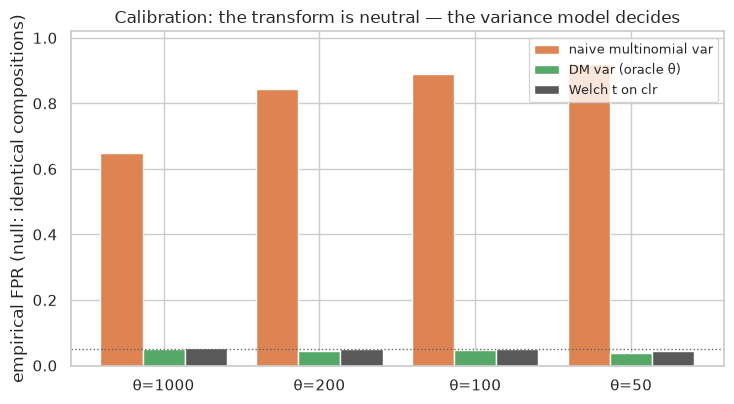

In [4]:
def welch_reject(a, b, alpha=0.05):
    a, b = np.asarray(a, float), np.asarray(b, float)
    nA, nB = a.shape[0], b.shape[0]
    mA, mB = a.mean(0), b.mean(0)
    vA, vB = a.var(0, ddof=1), b.var(0, ddof=1)
    se2 = vA / nA + vB / nB
    df = se2 ** 2 / ((vA / nA) ** 2 / (nA - 1) + (vB / nB) ** 2 / (nB - 1) + 1e-300)
    tcrit = st.t.ppf(1 - alpha / 2, df)
    return np.abs((mA - mB) / np.sqrt(se2)) > tcrit


def clr_fpr_experiment(theta, K=100, n=30, R=40, med_n=20_000, sigma_n=0.3, rng=None):
    rej = {"naive": [], "dm": [], "clr": []}
    for _ in range(R):
        pi = make_pi(K, rng, sigma=1.2, sort_descending=False)
        cntA, NA_ = simulate_group(pi, theta, n, 1.0, med_n, sigma_n, rng)
        cntB, NB_ = simulate_group(pi, theta, n, 1.0, med_n, sigma_n, rng)   # null: same pi
        pooled = (cntA.sum(0) + cntB.sum(0)) / (NA_.sum() + NB_.sum())
        keep = pooled * (NA_.mean() + NB_.mean()) >= 20                    # expressible genes
        xA, xB = (cntA / NA_[:, None]).mean(0), (cntB / NB_[:, None]).mean(0)
        p01 = pooled * (1 - pooled)
        with np.errstate(divide="ignore", invalid="ignore"):
            v_naive = p01 * (np.mean(1 / NA_) + np.mean(1 / NB_)) / n      # omits Dirichlet
            v_dm = p01 * (np.mean((NA_ + theta) / (NA_ * (1 + theta)))
                          + np.mean((NB_ + theta) / (NB_ * (1 + theta)))) / n
        z_n = (xB - xA) / np.sqrt(np.where(v_naive > 0, v_naive, np.inf))
        z_d = (xB - xA) / np.sqrt(np.where(v_dm > 0, v_dm, np.inf))
        rej["naive"].append(np.abs(z_n[keep]) > 1.96)
        rej["dm"].append(np.abs(z_d[keep]) > 1.96)
        rej["clr"].append(welch_reject(clr(cntB, 0.5)[:, keep], clr(cntA, 0.5)[:, keep]))
    return {m: np.concatenate(rej[m]).mean() for m in rej}


theta_grid = [1000.0, 200.0, 100.0, 50.0]
rows = {"naive multinomial var": [], "DM var (oracle θ)": [], "Welch t on clr": []}
for th in theta_grid:
    out = clr_fpr_experiment(th, rng=rng)
    rows["naive multinomial var"].append(out["naive"])
    rows["DM var (oracle θ)"].append(out["dm"])
    rows["Welch t on clr"].append(out["clr"])
    print(f"θ={th:>7g}  naive {out['naive']:.2f} | DM-var {out['dm']:.2f} | clr-Welch {out['clr']:.2f}")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
xx = np.arange(len(theta_grid))
w = 0.27
for k, (lbl, col) in enumerate(zip(rows, [COL_B, COL_M, "0.35"])):
    ax.bar(xx + (k - 1) * w, rows[lbl], width=w, color=col, label=lbl)
ax.axhline(0.05, color="0.4", ls=":", lw=1)
ax.set(xticks=xx, xticklabels=[f"θ={t:g}" for t in theta_grid], ylim=(0, 1.02),
       ylabel="empirical FPR (null: identical compositions)",
       title="Calibration: the transform is neutral — the variance model decides")
ax.legend(fontsize=9)
fig.tight_layout()

## 4. What median-of-ratios normalization actually does

DESeq2's size factors:
$s_s = \mathrm{median}_i\,(y_{si}+0.5)/g_i$, where $g_i$ is the *geometric mean of gene $i$
across samples* (genes with all-zero geomean are excluded — note how zero-friendly this
is compared to clr). The per-gene estimates then behave like:

$$
\widehat{\mathrm{LFC}}_i \;=\; \underbrace{\log_2\frac{\pi^{B}_i}{\pi^{A}_i}}_{\text{composition fold}} \;+\; \log_2\frac{s_A}{s_B}
\;=\; \log_2 m_i \;-\; \log_2 \mu_{\text{anchor}},
$$

i.e. **anchor-relative fold changes**: absolute expression folds $m_i$ if (and only if)
the anchor class (median gene, ≈ majority) is absolutely unchanged; otherwise every
estimate is dragged by the anchor's own fold. Empirical consequences, with per-sample
sequencing-efficiency noise $e_s\sim\operatorname{LogNormal}(0, 0.5^2)$ so that library
sizes vary for *rate* reasons too:

| truth | raw geomean LFC (no norm) | depth-normalized (composition fold) | MoR (anchor-relative) |
|---|---|---|---|
| $f{=}0.1$ up ×3, census | ✗ jointly shifted by rate noise | composition truth (+$\log_2 D/C$; dilution of rest) | ✓ ≈ absolute folds (anchor holds) |
| $f{=}0.6$ up ×3, census | ✗ same | composition truth | ✗ anchor wobbles into the majority class → biased (×3 genes compress, unchanged genes read as diluted) |

($D^* $ = composition fold of overexpressed genes; $C$ material multiplier.)
Demonstration below — 500 genes, $n=40$/group, $\theta=100$; the overexpressed sets are
random gene subsets (abundance-weighted material multipliers $C$ printed live).

f = 0.1 of genes: C = 1.23 | median N: A 33k, B 37k (nominal 37k) | 447/500 genes expressible
f = 0.6 of genes: C = 2.24 | median N: A 28k, B 57k (nominal 67k) | 468/500 genes expressible



median estimated log2FC [overexpressed | unchanged] (expressible genes):
  f = 0.1 of genes |   raw: +2.36 | -0.34
  f = 0.1 of genes | depth: +1.39 | -0.35
  f = 0.1 of genes |   MoR: +1.67 | -0.04
  f = 0.6 of genes |   raw: +1.42 | -1.12
  f = 0.6 of genes | depth: +0.48 | -1.27
  f = 0.6 of genes |   MoR: +1.45 | -0.29
-> raw: rate noise leaks in as a joint shift; depth: shows *composition* folds
   (overexpressed at +D/C, rest diluted by −log2 C); MoR: anchored — correct
   little-f truth, distorted when the majority itself is overexpressed.


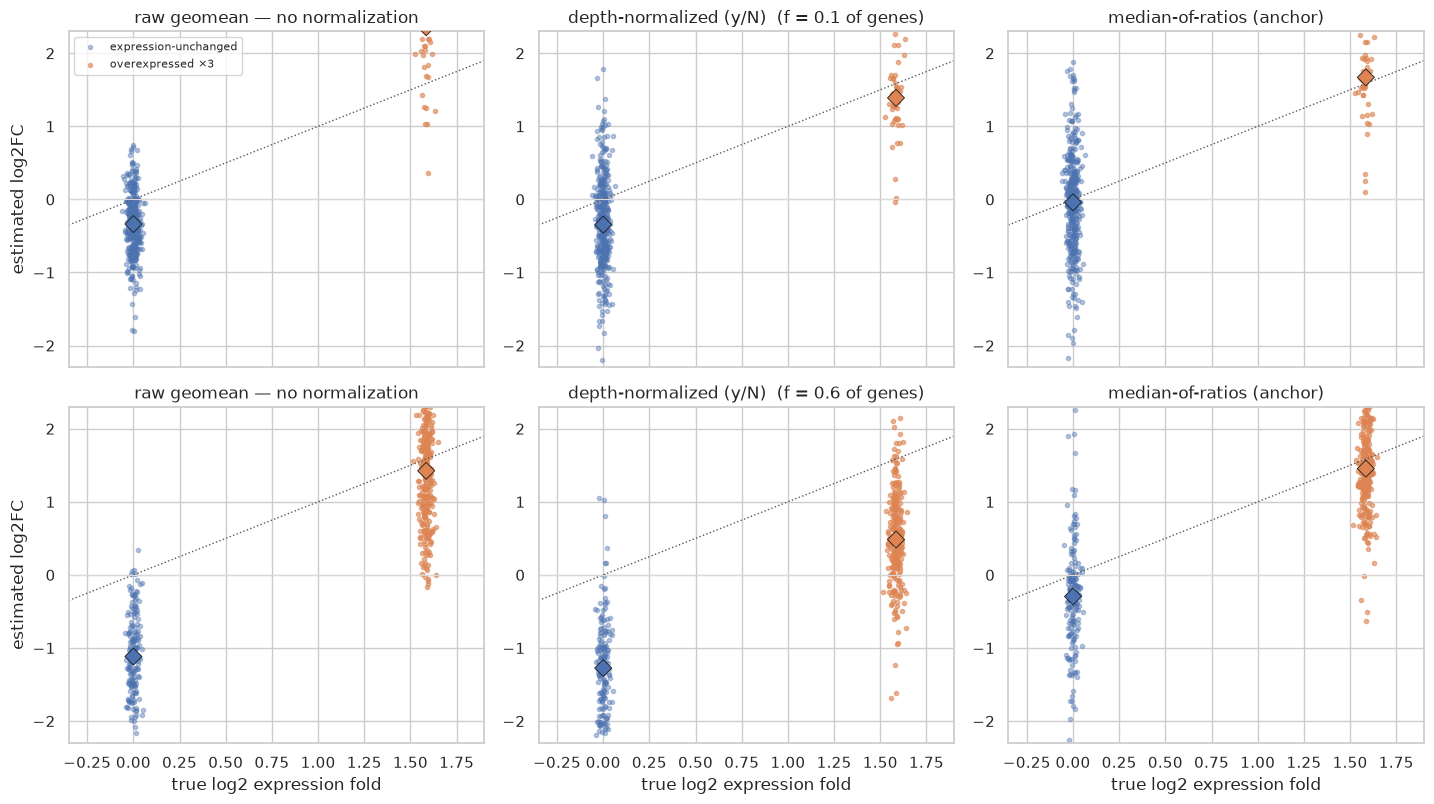

In [5]:
K4, N4 = 500, 100


def simulate_group_rates(pi, theta, n, material_factor=1.0, rate_sigma=0.5,
                         med_n=30_000, sigma_n=0.15, rng=None):
    # per-sample sequencing *rate/efficiency* e_s on top of material scaling
    P = np.vstack([rng.dirichlet(theta * pi) for _ in range(n)])
    e = rng.lognormal(0.0, rate_sigma, n)
    scale = rng.lognormal(np.log(med_n * material_factor), sigma_n, n)
    N = np.round(e * scale).astype(int)
    counts = np.vstack([rng.multinomial(N[t], P[t]) for t in range(n)])
    return counts, N


def mor_size_factors(counts):
    c = counts + 0.5
    geo = np.exp(np.log(c).mean(axis=0))
    return np.median(c / geo, axis=1)


def lfc_variants(cntA, NA_, cntB, NB_):
    half = cntA.shape[0]
    out = {}
    # raw: per-group pseudocount geomeans (finite by construction)
    out["raw"] = np.log2(np.exp(np.log(cntB + 0.5).mean(0))
                         / np.exp(np.log(cntA + 0.5).mean(0)))
    # depth and MoR: LINEAR means (zeros harmless), guarded floors
    out["depth"] = np.log2(np.maximum(mean_proportion(cntB, NB_), 1e-12)
                           / np.maximum(mean_proportion(cntA, NA_), 1e-12))
    base = np.vstack([cntA, cntB]).astype(float)
    sf = mor_size_factors(base)
    normed = base / sf[:, None]
    mA, mB = normed[:half].mean(0), normed[half:].mean(0)
    out["MoR"] = np.log2(np.maximum(mB, 1e-12) / np.maximum(mA, 1e-12))
    keep = base.mean(0) >= 10     # expressible genes only (sparse ones are noise)
    return out, keep


pi4 = make_pi(K4, rng, sigma=1.0, sort_descending=False)
results = {}
for name, frac in [("f = 0.1 of genes", 0.1), ("f = 0.6 of genes", 0.6)]:
    mask = np.zeros(K4, bool)
    mask[rng.choice(K4, int(round(frac * K4)), replace=False)] = True
    m = np.where(mask, 3.0, 1.0)
    piB, C = fold_pi(pi4, mask, 3.0)
    cntA, NA_ = simulate_group_rates(pi4, 100.0, N4, 1.0, rng=rng)
    cntB, NB_ = simulate_group_rates(piB, 100.0, N4, C, rng=rng)
    lv, keep = lfc_variants(cntA, NA_, cntB, NB_)
    results[name] = (lv, mask, np.log2(m), C, keep)
    print(f"{name}: C = {C:.2f} | median N: A {np.median(NA_)/1e3:.0f}k, "
          f"B {np.median(NB_)/1e3:.0f}k (nominal {30 * C:.0f}k) | "
          f"{keep.sum()}/{K4} genes expressible")

fig, axes = plt.subplots(2, 3, figsize=(14.5, 8.2), sharex=True)
methods = ["raw", "depth", "MoR"]
titles = {"raw": "raw geomean — no normalization", "depth": "depth-normalized (y/N)",
          "MoR": "median-of-ratios (anchor)"}
for r_, (name, (lfc, mask, true_log2, C, keep)) in enumerate(results.items()):
    jitter = rng.normal(0.0, 0.02, int(keep.sum()))
    tx, mk = true_log2[keep], mask[keep]
    for c_, meth in enumerate(methods):
        ax = axes[r_, c_]
        est = lfc[meth][keep]
        ax.scatter(tx[~mk] + jitter[~mk], est[~mk], s=9, alpha=0.4,
                   color=COL_A, label="expression-unchanged")
        ax.scatter(tx[mk] + jitter[mk], est[mk], s=9, alpha=0.6,
                   color=COL_B, label="overexpressed ×3")
        ax.scatter([0, np.log2(3)], [np.median(est[~mk]), np.median(est[mk])],
                   marker="D", s=75, c=[COL_A, COL_B], edgecolors="k",
                   linewidths=0.6, zorder=4)
        ax.plot([-0.35, 1.9], [-0.35, 1.9], color="0.35", ls=":", lw=1, zorder=1)
        ax.axhline(0, color="0.85", lw=0.8)
        ax.set(xlim=(-0.35, 1.9), ylim=(-2.3, 2.3),
               xlabel="true log2 expression fold" if r_ == 1 else None,
               ylabel="estimated log2FC" if c_ == 0 else None,
               title=f"{titles[meth]}  ({name})" if c_ == 1 else titles[meth])
        if r_ == 0 and c_ == 0:
            ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()

print("\nmedian estimated log2FC [overexpressed | unchanged] (expressible genes):")
for name, (lfc, mask, true_log2, C, keep) in results.items():
    for meth in methods:
        up = np.median(lfc[meth][keep][mask[keep]])
        un = np.median(lfc[meth][keep][~mask[keep]])
        print(f"  {name} | {meth:>5}: {up:+.2f} | {un:+.2f}")
print("-> raw: rate noise leaks in as a joint shift; depth: shows *composition* folds")
print("   (overexpressed at +D/C, rest diluted by −log2 C); MoR: anchored — correct")
print("   little-f truth, distorted when the majority itself is overexpressed.")

## Answers, restated

**Q1 — does CLR fill the DM's role?** No. Different layers:

* **CLR = coordinates + normalization.** It maps compositions into log-ratio space
  (Aitchison geometry), makes fold-changes relative to the *geometric mean of the
  current composition*, and is the right space for expressing *relative* shifts. That
  anchor role makes it a *cousin* of median-of-ratios: a clr fold change is exactly an
  anchor-relative LFC with anchor = geometric mean of all genes' fold factors (vs MoR:
  count-median anchor) — both merely *choose* the arbitrary scale.
* **DM = generative count model.** Multinomial ⊕ Dirichlet: explicit noise, natural
  zeros, likelihoods, a dispersion parameter with closed-form moments
  ($\operatorname{Var}\log p_i = \psi'(\alpha_i)-\psi'(\alpha_0)$ — verified against
  simulation to 4 decimals), and a valid route to calibrated tests and power.
* The correct CLR-land *distributional* analog of DM is the **logistic-normal(-multinomial)** —
  needed in any case because the Dirichlet structurally cannot express positive
  log-composition correlations (§1).
* Practical hybrids already exist: ALDEx2 = Dirichlet MC → clr → Welch; ANCOM's
  log-ratio tests; scVI-family etc. And zero-handling is where the transform hurts and
  the count model shines (§2: clr answer swings >1 log2 unit with the pseudocount;
  the prop-ratio estimate is stable).

**Q2 — impact of median-of-ratios?** It is an **anchor estimator**, not a fix for
identifiability:

1. **Removes scale noise**: size factors absorb library-size and efficiency variation —
   ≈ plain depth normalization when the majority is unchanged (§4, f = 0.1 row;
   raw-without-normalization leaks the efficiency noise in as a joint shift).
2. **Recover absolute folds iff the anchor holds** (§4, f = 0.1): MoR returns the true
   ×3 folds and 0 for the rest; depth-normalization instead returns *composition* folds
   (overexpressed at $+\log_2(D/C)$, unchanged genes diluted by $-\log_2 C$). MoR's extra
   step is the majority-rule assumption in action.
3. **Deletes/distorts global signals**: under census depth a global shift is exactly what
   the anchor absorbs. With $f = 0.6$ of genes overexpressed (§4), MoR's estimates pull
   off truth in *both* classes: the ×3 genes compress below $\log_2 3$ and the unchanged
   genes gain a spurious dilution — while plain depth-normalization stays at the
   compositional truth (the identifiability notebook's §5 shows the same mechanism with a
   geometric-mean aggregation, where the absorption quantifies to ≈ $\sqrt{D}$). This is
   *by design*: if you believe most genes don't move, removing a genome-wide factor is
   correcting an artifact; if the majority *did* move, it's erasing the answer.
4. **Zero-robust** in a way clr is not: zeros in a gene only exclude it from the *size
   factor* median computation, never break the estimator itself.
5. **No size-factor scheme (MoR, TMM, scran, depth) can resurrect the absolute scale** —
   the mirror and global-shift unidentifiabilities from
   `dm-overexpression-identifiability.ipynb` are properties of the observation process,
   not of the normalization.

In short: DM (or its logistic-normal cousin) answers *how counts are generated*;
CLR (or ILR/ALR) answers *where compositions sit in log-ratio space and how they should
be normalized*; MoR answers *which anchor the fold-changes are reported relative to*.
Stack them consciously — and only claim absolute statements if you've bought
identifiability (spike-ins / calibration), not just normalization.